<a href="https://colab.research.google.com/github/hit-by-git/CloudNative/blob/main/EM_on_GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

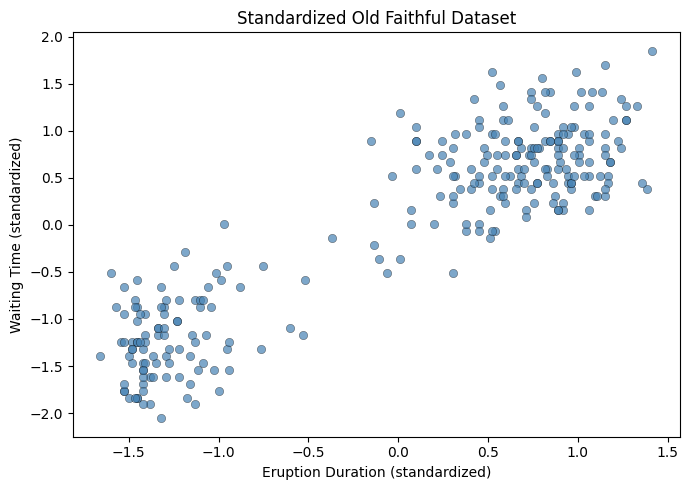

In [ ]:
df = pd.read_csv('faithful.csv')
df.columns = df.columns.str.strip()
X_raw = df[['eruptions', 'waiting']].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7, edgecolors='k', linewidths=0.3, color='steelblue')
plt.title('Standardized Old Faithful Dataset')
plt.xlabel('Eruption Duration (standardized)')
plt.ylabel('Waiting Time (standardized)')
plt.tight_layout()
plt.show()

K-Means converged at iteration 3


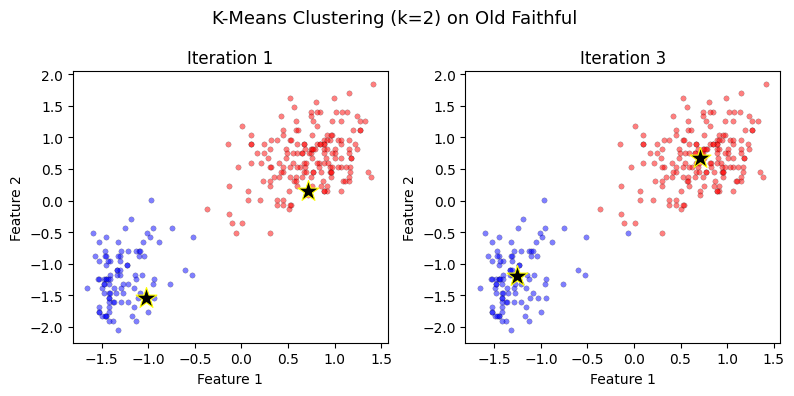

In [ ]:
np.random.seed(42)
idx = np.random.choice(len(X), 2, replace=False)
centers = X[idx].copy()

def assign_clusters(X, centers):
    dists = np.array([[np.linalg.norm(x - c) for c in centers] for x in X])
    return np.argmin(dists, axis=1)

def update_centers(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

plot_iters = {1, 5, 10, 15, 20}
history = []
labels = assign_clusters(X, centers)
history.append((1, labels.copy(), centers.copy()))

for it in range(2, 101):
    centers = update_centers(X, labels, 2)
    new_labels = assign_clusters(X, centers)
    if it in plot_iters:
        history.append((it, new_labels.copy(), centers.copy()))
    if np.all(new_labels == labels):
        if it not in plot_iters:
            history.append((it, new_labels.copy(), centers.copy()))
        print(f'K-Means converged at iteration {it}')
        break
    labels = new_labels

colors = ['red', 'blue']
n_plots = len(history)
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

for ax, (it, lbl, ctrs) in zip(axes, history):
    for k in range(2):
        ax.scatter(X[lbl == k, 0], X[lbl == k, 1], color=colors[k], alpha=0.5, s=15, edgecolors='k', linewidths=0.2)
    ax.scatter(ctrs[:, 0], ctrs[:, 1], color='black', marker='*', s=250, zorder=5, edgecolors='yellow', linewidths=0.8)
    ax.set_title(f'Iteration {it}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('K-Means Clustering (k=2) on Old Faithful', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def multivariate_gaussian(X, mu, Sigma):
    D = X.shape[1]
    diff = X - mu
    Sigma_inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    det = max(det, 1e-300)
    coeff = 1.0 / (np.sqrt((2 * np.pi) ** D * det))
    exponent = -0.5 * np.sum(diff @ Sigma_inv * diff, axis=1)
    return coeff * np.exp(exponent)

def e_step(X, pi, mus, Sigmas):
    K = len(pi)
    N = X.shape[0]
    r = np.zeros((N, K))
    for k in range(K):
        r[:, k] = pi[k] * multivariate_gaussian(X, mus[k], Sigmas[k])
    denom = r.sum(axis=1, keepdims=True)
    denom = np.where(denom == 0, 1e-300, denom)
    r = r / denom
    return r

def m_step(X, r, reg=0.0):
    N, K = r.shape
    D = X.shape[1]
    Nk = r.sum(axis=0)
    pi = Nk / N
    mus = (r.T @ X) / Nk[:, None]
    Sigmas = []
    for k in range(K):
        diff = X - mus[k]
        Sigma_k = (r[:, k:k+1] * diff).T @ diff / Nk[k]
        Sigma_k += reg * np.eye(D)
        Sigmas.append(Sigma_k)
    return pi, mus, Sigmas

def log_likelihood(X, pi, mus, Sigmas):
    K = len(pi)
    N = X.shape[0]
    likelihood = np.zeros(N)
    for k in range(K):
        likelihood += pi[k] * multivariate_gaussian(X, mus[k], Sigmas[k])
    likelihood = np.where(likelihood <= 0, 1e-300, likelihood)
    return np.sum(np.log(likelihood))

def draw_ellipse(ax, mu, Sigma, color, linewidth=2):
    vals, vecs = np.linalg.eigh(Sigma)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle,
                      edgecolor=color, fc='None', lw=linewidth, zorder=4)
    ax.add_patch(ellipse)

In [ ]:
mu1_init = np.array([-1.0, 1.0])
mu2_init = np.array([1.0, -1.0])
Sigma1_init = np.eye(2)
Sigma2_init = np.eye(2)
pi_init = np.array([0.5, 0.5])

pi = pi_init.copy()
mus = [mu1_init.copy(), mu2_init.copy()]
Sigmas = [Sigma1_init.copy(), Sigma2_init.copy()]

em_snapshots = {}
ll_history = []

r_after_first_estep = e_step(X, pi, mus, Sigmas)
em_snapshots['E1'] = (r_after_first_estep.copy(), [m.copy() for m in mus], [s.copy() for s in Sigmas])

plot_cycles = {2, 5, 10, 15, 20}

for cycle in range(1, 21):
    r = e_step(X, pi, mus, Sigmas)
    pi, mus, Sigmas = m_step(X, r)
    ll = log_likelihood(X, pi, mus, Sigmas)
    ll_history.append(ll)
    if cycle in plot_cycles:
        r_snap = e_step(X, pi, mus, Sigmas)
        em_snapshots[cycle] = (r_snap.copy(), [m.copy() for m in mus], [s.copy() for s in Sigmas])

print(f'Final log-likelihood: {ll_history[-1]:.4f}')
print(f'Final mixing coefficients: pi1={pi[0]:.4f}, pi2={pi[1]:.4f}')
print(f'Final mu1: {mus[0]}')
print(f'Final mu2: {mus[1]}')

Final log-likelihood: -541.9673
Final mixing coefficients: pi1=0.5105, pi2=0.4895
Final mu1: [-0.1715543   0.08065006]
Final mu2: [ 0.1788993  -0.08410305]


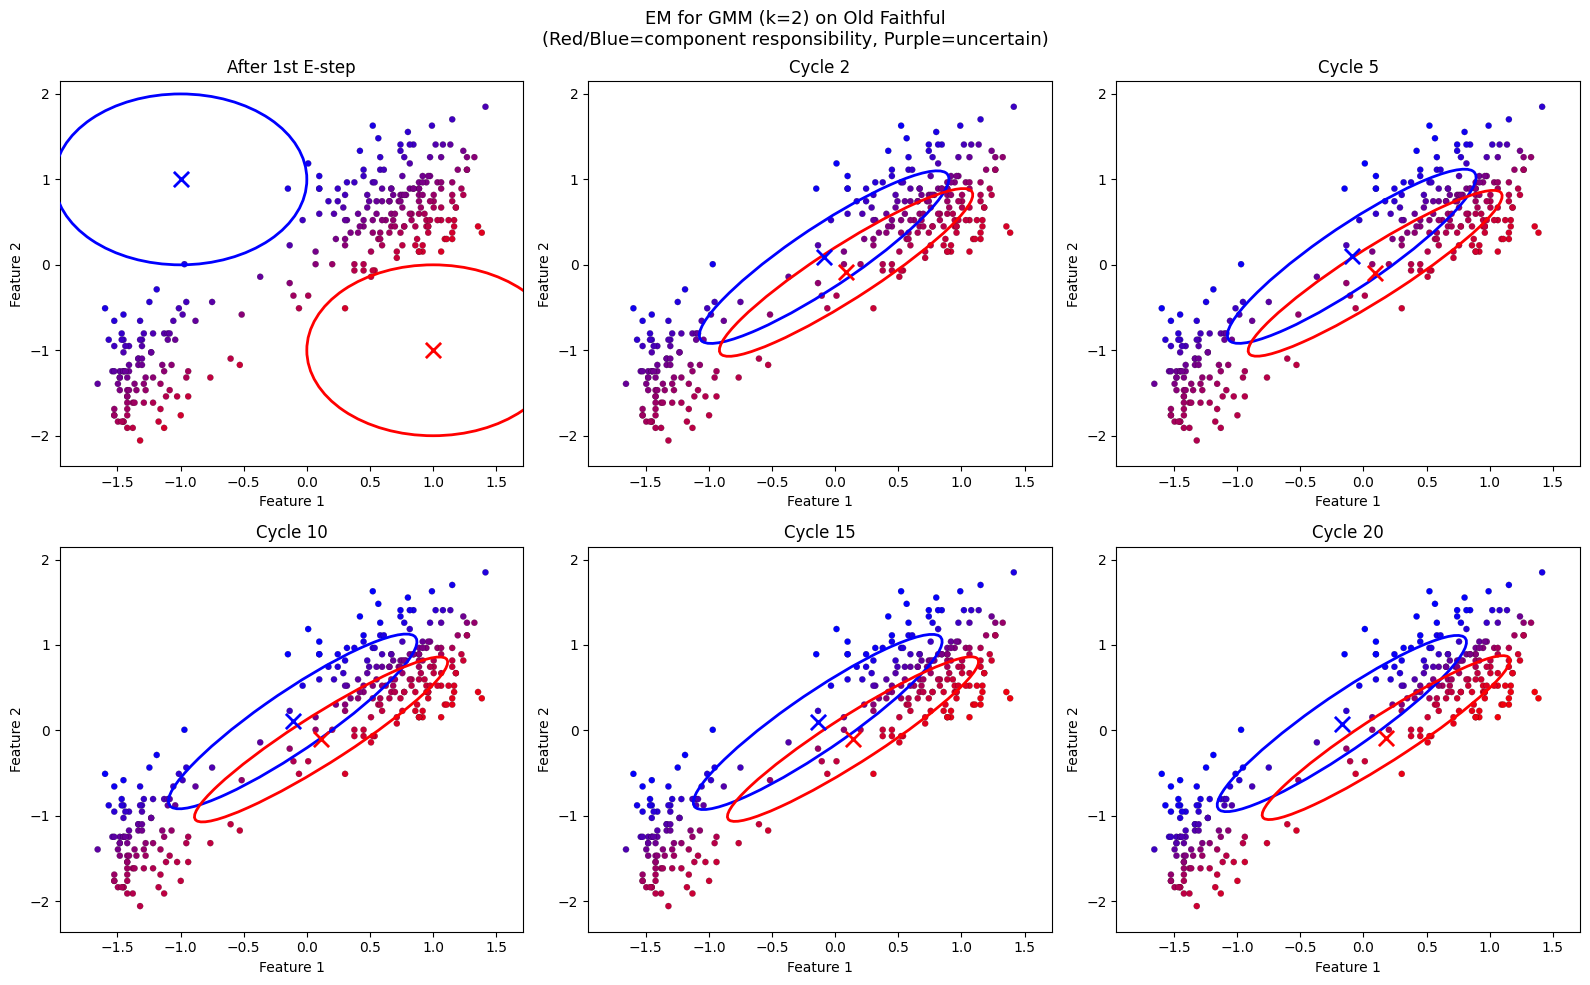

In [ ]:
snap_keys = ['E1', 2, 5, 10, 15, 20]
snap_labels = ['After 1st E-step', 'Cycle 2', 'Cycle 5', 'Cycle 10', 'Cycle 15', 'Cycle 20']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (key, label) in enumerate(zip(snap_keys, snap_labels)):
    ax = axes[idx]
    r_snap, mus_snap, Sigmas_snap = em_snapshots[key]

    r_blue = r_snap[:, 0]
    r_red = r_snap[:, 1]
    point_colors = np.stack([r_red, np.zeros(len(X)), r_blue], axis=1)
    point_colors = np.clip(point_colors, 0, 1)

    ax.scatter(X[:, 0], X[:, 1], color=point_colors, s=20, edgecolors='k', linewidths=0.1, zorder=3)
    draw_ellipse(ax, mus_snap[0], Sigmas_snap[0], color='blue', linewidth=2)
    draw_ellipse(ax, mus_snap[1], Sigmas_snap[1], color='red', linewidth=2)
    ax.scatter(*mus_snap[0], color='blue', marker='x', s=120, zorder=5, linewidths=2)
    ax.scatter(*mus_snap[1], color='red', marker='x', s=120, zorder=5, linewidths=2)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_xlim(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3)
    ax.set_ylim(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3)

plt.suptitle('EM for GMM (k=2) on Old Faithful\n(Red/Blue=component responsibility, Purple=uncertain)', fontsize=13)
plt.tight_layout()
plt.show()

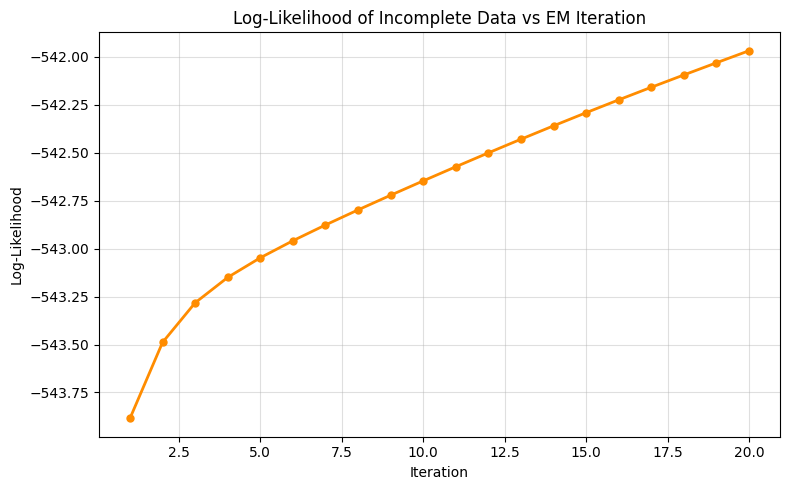

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ll_history) + 1), ll_history, marker='o', color='darkorange', linewidth=2, markersize=5)
plt.title('Log-Likelihood of Incomplete Data vs EM Iteration')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
singular_point = X[0].copy()

pi_s = np.array([0.5, 0.5])
mus_s = [singular_point.copy(), np.array([1.0, -1.0])]
Sigmas_s = [0.001 * np.eye(2), np.eye(2)]

ll_before_crash = None
crash_error = None
crash_iter = None

for cycle in range(1, 51):
    try:
        r_s = e_step(X, pi_s, mus_s, Sigmas_s)
        ll_now = log_likelihood(X, pi_s, mus_s, Sigmas_s)
        if not np.isfinite(ll_now):
            raise ValueError(f'Log-likelihood is {ll_now} — numerical singularity detected (infinite or NaN)')
        ll_before_crash = ll_now
        pi_s, mus_s, Sigmas_s = m_step(X, r_s, reg=0.0)
        det1 = np.linalg.det(Sigmas_s[0])
        if det1 < 1e-20:
            raise np.linalg.LinAlgError(f'Covariance matrix is singular or near-singular: det={det1:.2e}. '
                                        f'This happens when a Gaussian collapses onto a single data point.')
    except (np.linalg.LinAlgError, ValueError, FloatingPointError) as e:
        crash_error = str(e)
        crash_iter = cycle
        print(f'CRASH at iteration {cycle}')
        print(f'Error: {e}')
        print(f'Log-likelihood right before crash: {ll_before_crash:.6f}')
        break

CRASH at iteration 3
Error: Covariance matrix is singular or near-singular: det=4.37e-35. This happens when a Gaussian collapses onto a single data point.
Log-likelihood right before crash: -538.887495


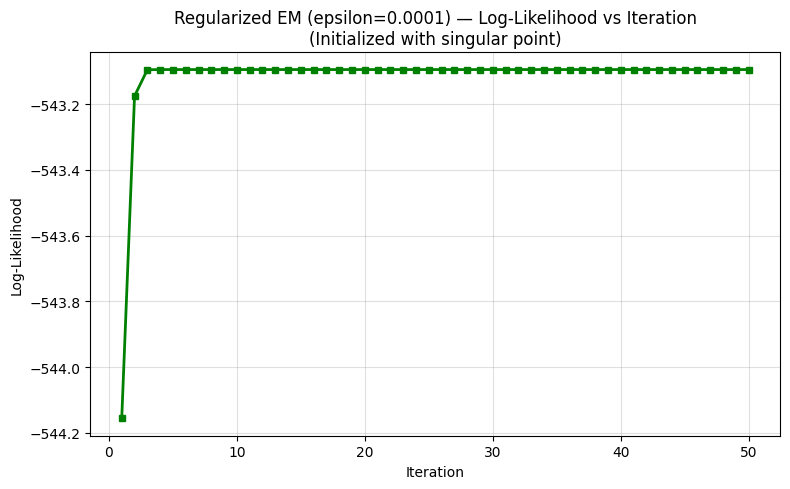

Final log-likelihood (regularized): -543.0943
Final mu1: [0.15562879 0.59712344]
Final mu2: [-0.00095793 -0.00367543]
Final pi: [0.00611757 0.99388243]


In [ ]:
epsilon = 1e-4

pi_reg = np.array([0.5, 0.5])
mus_reg = [singular_point.copy(), np.array([1.0, -1.0])]
Sigmas_reg = [0.001 * np.eye(2), np.eye(2)]

ll_reg_history = []

for cycle in range(1, 51):
    r_reg = e_step(X, pi_reg, mus_reg, Sigmas_reg)
    pi_reg, mus_reg, Sigmas_reg = m_step(X, r_reg, reg=epsilon)
    ll_reg = log_likelihood(X, pi_reg, mus_reg, Sigmas_reg)
    ll_reg_history.append(ll_reg)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ll_reg_history) + 1), ll_reg_history, marker='s', color='green', linewidth=2, markersize=5)
plt.title(f'Regularized EM (epsilon={epsilon}) — Log-Likelihood vs Iteration\n(Initialized with singular point)')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Final log-likelihood (regularized): {ll_reg_history[-1]:.4f}')
print(f'Final mu1: {mus_reg[0]}')
print(f'Final mu2: {mus_reg[1]}')
print(f'Final pi: {pi_reg}')

In [ ]:
def e_step_fixed_cov(X, pi, mus, epsilon):
    K = len(pi)
    D = X.shape[1]
    Sigma_fixed = epsilon * np.eye(D)
    Sigmas_fixed = [Sigma_fixed] * K
    return e_step(X, pi, mus, Sigmas_fixed)

def run_em_fixed_cov(X, epsilon, n_iter=50):
    np.random.seed(42)
    idx = np.random.choice(len(X), 2, replace=False)
    mus = [X[idx[0]].copy(), X[idx[1]].copy()]
    pi = np.array([0.5, 0.5])
    Sigmas = [epsilon * np.eye(X.shape[1])] * 2
    ll_hist = []
    for _ in range(n_iter):
        r = e_step_fixed_cov(X, pi, mus, epsilon)
        pi, mus, _ = m_step(X, r, reg=0.0)
        ll = log_likelihood(X, pi, mus, [epsilon * np.eye(X.shape[1])] * 2)
        ll_hist.append(ll)
    r_final = e_step_fixed_cov(X, pi, mus, epsilon)
    return r_final, mus, ll_hist

epsilons = [1.0, 0.1, 0.001]
results_part3 = {}
for eps in epsilons:
    r_f, mus_f, ll_f = run_em_fixed_cov(X, eps)
    results_part3[eps] = (r_f, mus_f, ll_f)
    print(f'epsilon={eps}: final ll={ll_f[-1]:.4f}, mu1={mus_f[0]}, mu2={mus_f[1]}')

epsilon=1.0: final ll=-703.2800, mu1=[0.6414318  0.62176512], mu2=[-1.18670162 -1.15031664]
epsilon=0.1: final ll=-448.0205, mu1=[0.70945464 0.67496746], mu2=[-1.26293549 -1.20154315]
epsilon=0.001: final ll=-37278.3199, mu1=[0.72839716 0.69932748], mu2=[-1.27558865 -1.22138475]


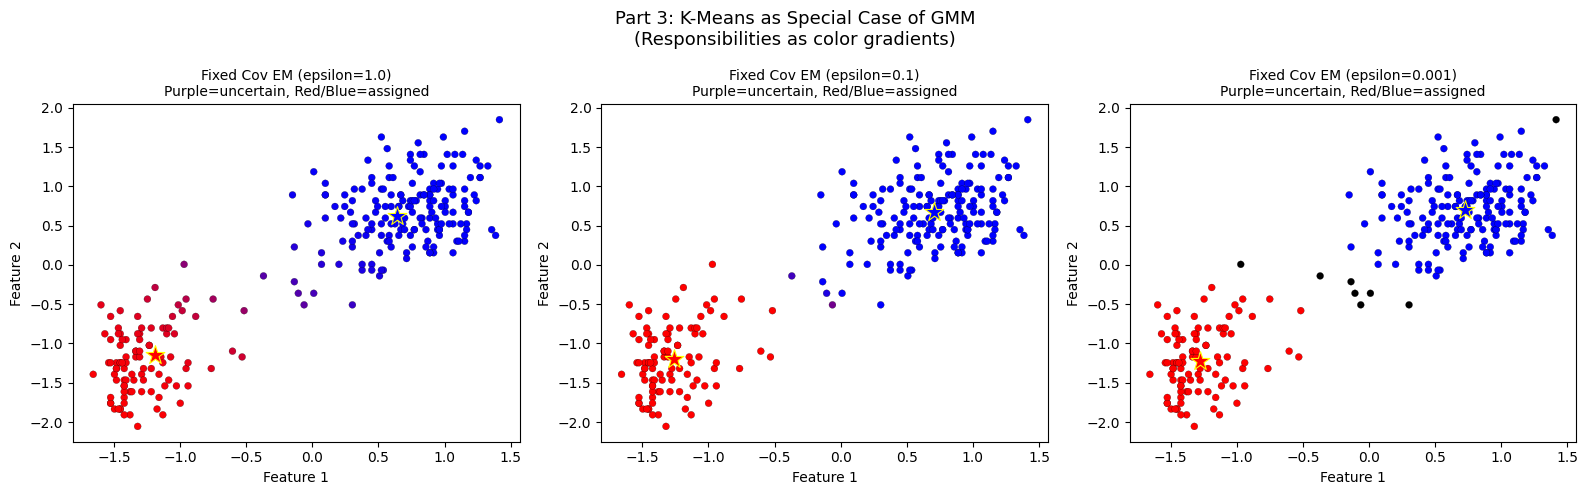

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, eps in zip(axes, epsilons):
    r_f, mus_f, _ = results_part3[eps]
    r_blue = r_f[:, 0]
    r_red = r_f[:, 1]
    point_colors = np.stack([r_red, np.zeros(len(X)), r_blue], axis=1)
    point_colors = np.clip(point_colors, 0, 1)
    ax.scatter(X[:, 0], X[:, 1], color=point_colors, s=25, edgecolors='k', linewidths=0.15, zorder=3)
    ax.scatter(*mus_f[0], color='blue', marker='*', s=200, zorder=5, edgecolors='yellow', linewidths=0.8)
    ax.scatter(*mus_f[1], color='red', marker='*', s=200, zorder=5, edgecolors='yellow', linewidths=0.8)
    ax.set_title(f'Fixed Cov EM (epsilon={eps})\nPurple=uncertain, Red/Blue=assigned', fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Part 3: K-Means as Special Case of GMM\n(Responsibilities as color gradients)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(0)
D = 50
K_true = 3
N_per = 167
means_true = [
    np.random.randn(D) * 2,
    np.random.randn(D) * 2,
    np.random.randn(D) * 2
]
X_hd_parts = [np.random.multivariate_normal(means_true[k], np.eye(D), N_per) for k in range(K_true)]
X_hd = np.vstack(X_hd_parts)
y_hd_true = np.array([k for k in range(K_true) for _ in range(N_per)])
print(f'High-dimensional dataset shape: {X_hd.shape}')

High-dimensional dataset shape: (501, 50)


In [ ]:
def run_em_hd(X, K=3, n_iter=100, reg=1e-3, seed=42):
    np.random.seed(seed)
    N, D = X.shape
    idx = np.random.choice(N, K, replace=False)
    mus = [X[idx[k]].copy() for k in range(K)]
    Sigmas = [np.eye(D) for _ in range(K)]
    pi = np.ones(K) / K
    ll_hist = []
    cond_nums = []

    for it in range(n_iter):
        N_pts = X.shape[0]
        r = np.zeros((N_pts, K))
        for k in range(K):
            r[:, k] = pi[k] * multivariate_gaussian(X, mus[k], Sigmas[k])
        denom = r.sum(axis=1, keepdims=True)
        denom = np.where(denom == 0, 1e-300, denom)
        r = r / denom

        Nk = r.sum(axis=0)
        pi = Nk / N_pts
        mus = [(r[:, k:k+1] * X).sum(axis=0) / Nk[k] for k in range(K)]
        new_Sigmas = []
        for k in range(K):
            diff = X - mus[k]
            Sk = (r[:, k:k+1] * diff).T @ diff / Nk[k]
            Sk += reg * np.eye(D)
            new_Sigmas.append(Sk)
        Sigmas = new_Sigmas

        ll = log_likelihood(X, pi, mus, Sigmas)
        ll_hist.append(ll)

        cns = [np.linalg.cond(S) for S in Sigmas]
        cond_nums.append(cns)

        if it > 5 and abs(ll_hist[-1] - ll_hist[-2]) < 1e-4:
            print(f'HD EM converged at iteration {it+1}')
            break

    return pi, mus, Sigmas, ll_hist, np.array(cond_nums)

pi_hd, mus_hd, Sigmas_hd, ll_hd, cond_hd = run_em_hd(X_hd, K=3, n_iter=100, reg=1e-3)

HD EM converged at iteration 9


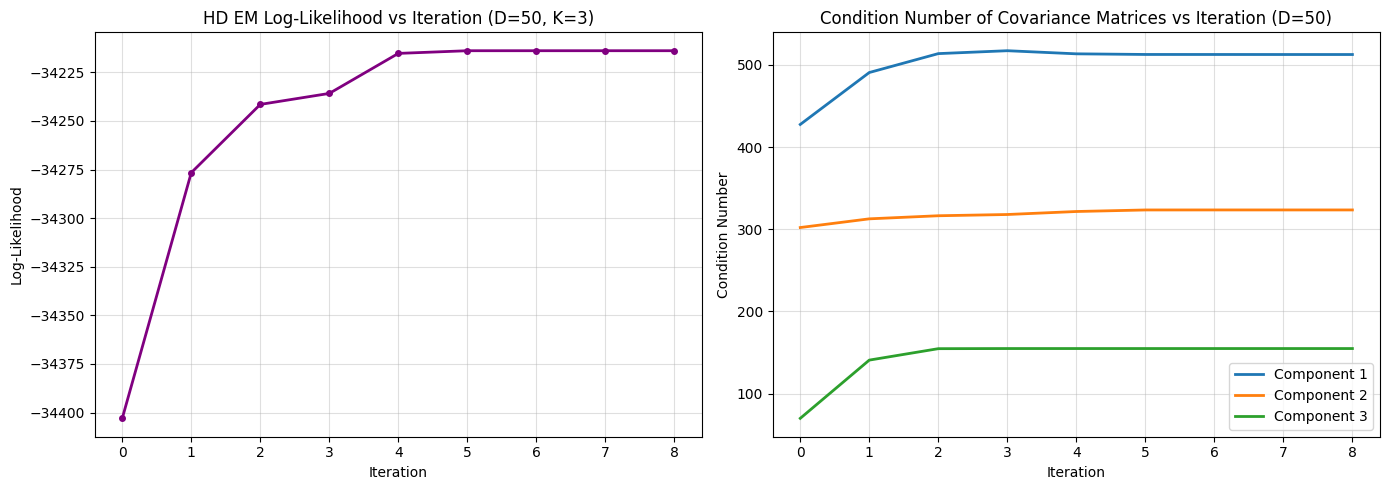


Final condition numbers of covariance matrices:
  Component 1: cond=512.55
  Component 2: cond=323.44
  Component 3: cond=154.80

Final log-likelihood: -34213.8688
Final mixing coefficients: [0.27554434 0.59271934 0.13173632]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ll_hd, marker='o', color='purple', linewidth=2, markersize=4)
axes[0].set_title('HD EM Log-Likelihood vs Iteration (D=50, K=3)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Log-Likelihood')
axes[0].grid(True, alpha=0.4)

for k in range(3):
    axes[1].plot(cond_hd[:, k], label=f'Component {k+1}', linewidth=2)
axes[1].set_title('Condition Number of Covariance Matrices vs Iteration (D=50)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Condition Number')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('\nFinal condition numbers of covariance matrices:')
for k in range(3):
    print(f'  Component {k+1}: cond={np.linalg.cond(Sigmas_hd[k]):.2f}')
print(f'\nFinal log-likelihood: {ll_hd[-1]:.4f}')
print(f'Final mixing coefficients: {pi_hd}')